In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.image import load_img, index_img, math_img, new_img_like, resample_to_img
from nilearn.plotting import (plot_img, plot_stat_map, plot_design_matrix, 
plot_contrast_matrix, plot_roi, plot_connectome, show, find_parcellation_cut_coords)
from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm import threshold_stats_img
from nilearn.reporting import get_clusters_table
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import datasets
import warnings
warnings.filterwarnings("ignore")

In [2]:
phenotype = pd.read_csv('../Pediatric_Anxiety_Disorder/phenotype/phenotype.tsv', delimiter="\t")
phenotype.head()

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,...,DOT_PROBE_BASELINE_BIAS,DOT_PROBE_BASELINE_ABV,DOT_PROBE_BASELINE_DDM_DRIFT_RATE,DOT_PROBE_BASELINE_DDM_BIAS,DOT_PROBE_T2_ACCURACY,DOT_PROBE_T2_MEDIAN_RT_CONGRUENT,DOT_PROBE_T2_MEDIAN_RT_INCONGRUENT,DOT_PROBE_T2_MEDIAN_RT_NEUTRAL,DOT_PROBE_T2_BIAS,DOT_PROBE_T2_ABV
0,sub-020131,1,17,HV,122.0,8.0,1,-1,-1,-1,...,-26.62,0.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sub-020209,1,16,HV,118.0,8.0,1,-1,-1,-1,...,-5.21,0.07,5.04,0.01,NaN,NaN,NaN,NaN,NaN,NaN
2,sub-020725,1,14,HV,116.0,8.0,1,-1,-1,-1,...,-21.97,0.07,6.57,-0.04,NaN,NaN,NaN,NaN,NaN,NaN
3,sub-021100,-1,11,HV,134.0,8.0,1,-1,-1,-1,...,16.49,0.10,3.71,0.02,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-021214,1,11,HV,130.0,9.0,1,-1,-1,-1,...,4.83,0.06,5.28,-0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
1 if phenotype[phenotype['participant_id']=='sub-022172']['COHORT'].values[0]==1 else 2

2

In [4]:
'Anxiety' if phenotype[phenotype['participant_id']=='sub-022172']['KSADS_MAIN_DIAGNOSIS'].values[0]== 'ANX' else 'Healthy'

'Healthy'

In [5]:
# HYPERPARAMETERS
HRF_MODEL = 'spm'
DRIFT_MODEL = 'cosine'
HIGH_PASS = 0.01
STANDARDIZE = 'zscore_sample'
SMOOTHING = 6
ALPHA = 0.1
CLUSTERS = 5
HEIGHT_CONTROL = 'fpr'
NUM_CLUSTERS = 10

# FMRI PROPERTIES
TASK_TR = 2.3
REST_TR = 2
SLICE_TIME_REF = 0.0

In [6]:
# TEs for Cohort 2
TEs = [14.8, 28.4, 42.0]

In [7]:
# CONTRASTS
CONTRASTS = {
    "congruent_effect": "congruent",
    "incongruent_effect": "incongruent",
    "neutral_effect": "neutral",
    "incongruent_vs_congruent": "incongruent - congruent",
    "incongruent_vs_neutral": "incongruent - neutral",
    "neutral_vs_congruent": "neutral - congruent",
    "task_vs_baseline": "(congruent + incongruent + neutral) / 3",
    "error_monitoring": "error - (congruent + incongruent + neutral) / 3"
}

In [8]:
subjects = [20131, 22286, 23842, 24050]
subjects_info = []
for subject in subjects:
    sub_id = 'sub-0'+str(subject)
    sub_info = {
        'subject_id': str(subject),
        'cohort': 1 if phenotype[phenotype['participant_id']==sub_id]['COHORT'].values[0]==1 else 2,
        'diagnosis': 'Anxiety' if phenotype[phenotype['participant_id']==sub_id]['KSADS_MAIN_DIAGNOSIS'].values[0]== 'ANX' else 'Healthy'
    }
    subjects_info.append(sub_info)

In [9]:
subjects_info

[{'subject_id': '20131', 'cohort': 1, 'diagnosis': 'Healthy'},
 {'subject_id': '22286', 'cohort': 1, 'diagnosis': 'Anxiety'},
 {'subject_id': '23842', 'cohort': 2, 'diagnosis': 'Anxiety'},
 {'subject_id': '24050', 'cohort': 2, 'diagnosis': 'Healthy'}]

In [10]:
sub_info = subjects_info[0]

In [11]:
print(f"Subject {sub_info['subject_id']} - {sub_info['diagnosis']} - Cohort {sub_info['cohort']}\n")

# Paths
subject_path = os.path.join('..', 'Pediatric_Anxiety_Disorder', 'sub-'+sub_info['subject_id'], 'ses-1')
func_path = os.path.join(subject_path, 'func')
struct_path = os.path.join(subject_path, 'anat')
run1_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-1_bold.nii')
run2_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-2_bold.nii')
mean_path = os.path.join(func_path, f'wmeanasub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-1_bold.nii')
run1_events_path = os.path.join(func_path, f'sub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-1_events.tsv')
run2_events_path = os.path.join(func_path, f'sub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-2_events.tsv')
run1_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-1_bold.txt')
run2_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-2_bold.txt')
anat_path = os.path.join(struct_path, f'sub-{sub_info['subject_id']}_ses-1_T1w.nii')
if sub_info['cohort']==1:
    rest_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-rest_bold.nii')
    rest_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-rest_bold.txt')
else:
    rest_echo1_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-rest_echo-1_bold.nii')
    rest_echo1_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-rest_echo-1_bold.txt')
    rest_echo2_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-rest_echo-2_bold.nii')
    rest_echo2_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-rest_echo-2_bold.txt')
    rest_echo3_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-rest_echo-3_bold.nii')
    rest_echo3_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-rest_echo-3_bold.txt')

# Loading images
run1 = load_img(run1_path)
run2 = load_img(run2_path)
mean_fmri = load_img(mean_path)
anat = load_img(anat_path)
if sub_info['cohort']==1:
    rest = load_img(rest_path)
else:
    rest_echo1 = load_img(rest_echo1_path)
    rest_echo2 = load_img(rest_echo2_path)
    rest_echo3 = load_img(rest_echo3_path)

# Loading tables
run1_events_table = pd.read_table(run1_events_path)[['onset','duration','trial_type']]
run2_events_table = pd.read_table(run2_events_path)[['onset','duration','trial_type']]
run1_confounds_table = pd.read_table(run1_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
run2_confounds_table = pd.read_table(run2_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
if sub_info['cohort']==1:
    rest_confounds_table = pd.read_table(rest_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
else:
    rest_echo1_confounds_table = pd.read_table(rest_echo1_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
    rest_echo2_confounds_table = pd.read_table(rest_echo2_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
    rest_echo3_confounds_table = pd.read_table(rest_echo3_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')

Subject 20131 - Healthy - Cohort 1



In [12]:
# First-level GLM
fl_glm = FirstLevelModel(
    t_r=TASK_TR,
    slice_time_ref=SLICE_TIME_REF,
    smoothing_fwhm=SMOOTHING,
    hrf_model=HRF_MODEL,
    drift_model=DRIFT_MODEL,
    high_pass=HIGH_PASS,
    standardize=STANDARDIZE,
    n_jobs=-1,
    verbose=1
)

fl_glm.fit([run1, run2], 
           events=[run1_events_table, run2_events_table],
           confounds=[run1_confounds_table, run2_confounds_table]
          )

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x000001A32A4D00E0>

[FirstLevelModel.fit] Computing mask

[FirstLevelModel.fit] Resamping mask

[FirstLevelModel.fit] Finished fit

[FirstLevelModel.fit] Computing run 1 out of 2 runs (go take a coffee, a big one).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x000001A32A4D00E0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 4 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 12 seconds.

[FirstLevelModel.fit] Computing run 2 out of 2 runs (17 seconds remaining).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x000001A32A614710>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 6 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 5 seconds.

[FirstLevelModel.fit] Computation of 2 runs done in 29 seconds.

,t_r,2.3
,slice_time_ref,0.0
,hrf_model,'spm'
,drift_model,'cosine'
,high_pass,0.01
,drift_order,1
,fir_delays,None
,min_onset,-24
,mask_img,None
,target_affine,None
,target_shape,None


In [13]:
contrast_name = 'incongruent_vs_congruent'
testing = 'Incongruent > Congruent'

[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

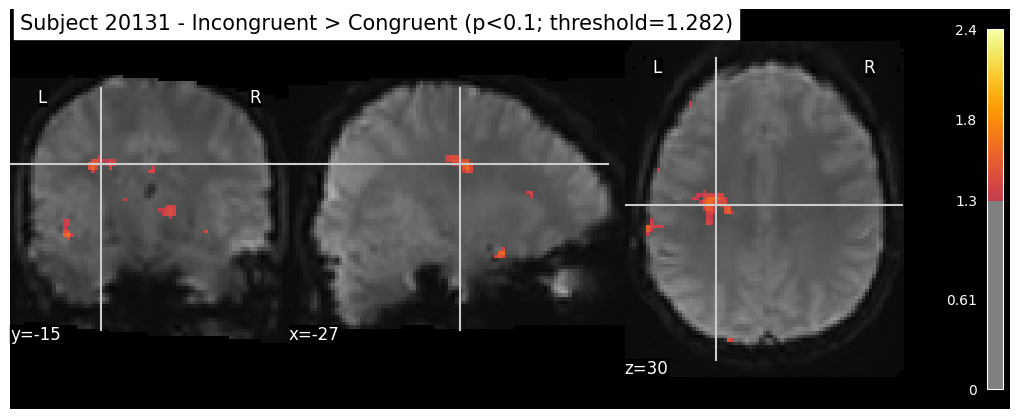

In [14]:
# Incongruent vs Congruent Contrast testing
contrast_outputs = fl_glm.compute_contrast(
    contrast_def=CONTRASTS[contrast_name],
    stat_type='t',
    output_type='all'
)

clean_z_map, threshold_z = threshold_stats_img(
    contrast_outputs['z_score'],
    alpha=ALPHA,
    height_control=HEIGHT_CONTROL,
    two_sided=False
)

plotting_config = {
    'bg_img': mean_fmri,
    'cmap': 'inferno',
    'black_bg': True
}

plot_stat_map(
    clean_z_map,
    threshold=threshold_z,
    title=f"Subject {sub_info['subject_id']} - {testing} (p<{ALPHA}; threshold={threshold_z:.3f})",
    figure=plt.figure(figsize=(10,4)),
    **plotting_config
)
show()

In [15]:
# Cluster Map
cluster_table, cluster_label_map = get_clusters_table(
    stat_img=clean_z_map,
    stat_threshold=threshold_z,
    cluster_threshold=0,
    two_sided=False,
    return_label_maps=True
)

print(f"Subject {sub_info['subject_id']} - Clusters:")
display(cluster_table)

cluster_map = cluster_label_map[0]

print(f"\nSubject {sub_info['subject_id']} - Number of clusters found in {testing}: {len(np.unique(cluster_map.get_fdata())) - 1}")

# Cluster coordinates
cluster_coordinates = find_parcellation_cut_coords(cluster_map)
print(f"Subject {sub_info['subject_id']} - Cluster coordinates:\n {cluster_coordinates}")

Subject 20131 - Clusters:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,26.0,-98.0,-2.0,2.437438,264
1,2,-18.0,-92.0,34.0,2.406934,240
2,3,-38.0,0.0,-18.0,2.097505,408
3,4,14.0,68.0,0.0,1.946398,1384
4,4a,18.0,56.0,-6.0,1.787068,
...,...,...,...,...,...,...
69,63,6.0,-54.0,-62.0,1.293786,8
70,64,16.0,-26.0,-6.0,1.289604,8
71,65,-20.0,48.0,-6.0,1.288262,8
72,66,-18.0,-98.0,12.0,1.287772,8



Subject 20131 - Number of clusters found in Incongruent > Congruent: 67
Subject 20131 - Cluster coordinates:
 [[  27.21212121  -95.03030303   -0.78787879]
 [ -19.4         -90.13333333   34.06666667]
 [ -38.2745098     0.54901961  -18.35294118]
 [  15.19075145   64.46242775   -1.49132948]
 [ -46.4         -15.49090909   -5.89090909]
 [ -10.93333333  -53.06666667  -60.        ]
 [  58.22222222    6.33333333  -12.11111111]
 [  14.77419355   54.77419355   18.4516129 ]
 [  40.            5.           14.        ]
 [ -27.96551724  -16.09195402   30.16091954]
 [  -6.41666667 -102.08333333   -6.16666667]
 [   3.2         -49.6         -62.        ]
 [ -27.33333333    6.47619048  -20.76190476]
 [ -43.46153846   38.30769231   27.15384615]
 [ -16.           72.           18.        ]
 [ -63.          -27.375        30.25      ]
 [  -5.53846154  -76.76923077   -2.46153846]
 [ -62.            3.           28.        ]
 [ -48.1           1.9         -10.3       ]
 [ -47.           -4.5           6

In [16]:
# Schaefer 100 Atlas
atlas = datasets.fetch_atlas_schaefer_2018(
    n_rois=100,
    yeo_networks=7,
    resolution_mm=2
)

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\aleen\nilearn_data\schaefer_2018

In [17]:
atlas.keys()

dict_keys(['maps', 'labels', 'description', 'lut', 'atlas_type', 'template'])

In [18]:
load_img(atlas.maps).shape

(91, 109, 91)

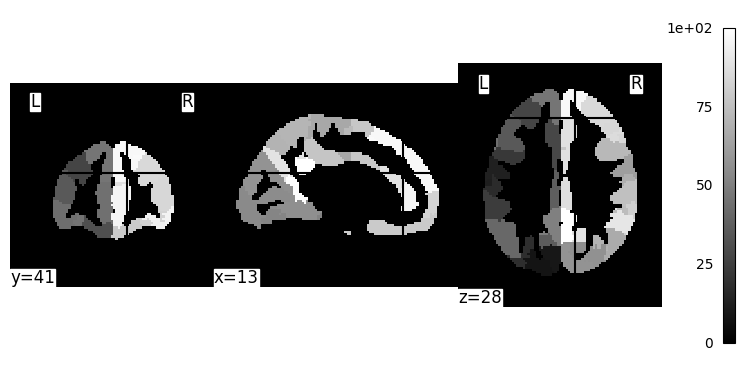

In [19]:
plot_img(atlas.maps)
show()

In [20]:
mean_fmri.shape, run1.shape, rest.shape

((79, 95, 79), (79, 95, 79, 184), (79, 95, 79, 180))

In [21]:
resampled_atlas = resample_to_img(atlas.maps, mean_fmri, interpolation='nearest')
resampled_atlas.shape

(79, 95, 79)

In [22]:
atlas_coordinates = find_parcellation_cut_coords(resampled_atlas)
print(len(atlas_coordinates))
print(atlas_coordinates)

100
[[-2.58197970e+01 -3.26243655e+01 -1.74593909e+01]
 [-2.54812881e+01 -7.65918190e+01 -1.35143603e+01]
 [-1.64249471e+01 -6.09577167e+01 -6.73572939e+00]
 [-2.71308176e+01 -9.44905660e+01 -4.74465409e+00]
 [-6.22650602e+00 -9.24626506e+01 -3.03614458e+00]
 [-1.26992864e+01 -6.49643221e+01  5.78797146e+00]
 [-4.70372737e+01 -7.08178914e+01  1.05175719e+01]
 [-2.57454545e+01 -8.80149733e+01  2.04973262e+01]
 [-8.30476190e+00 -8.10645503e+01  2.66645503e+01]
 [-5.31723220e+01 -2.24071856e+01  7.94278110e+00]
 [-3.72030361e+01 -2.11537002e+01  1.55104364e+01]
 [-5.45261228e+01 -1.13253896e+01  1.35838680e+01]
 [-5.46137184e+01 -8.24909747e+00  3.34386282e+01]
 [-3.92759009e+01 -2.31936937e+01  5.89256757e+01]
 [-1.13042712e+01 -2.64588287e+01  6.36715103e+01]
 [-4.66188870e+01 -5.68271501e+01 -1.25168634e+01]
 [-5.74897025e+01 -2.49977117e+01  3.85080092e+01]
 [-2.50340843e+01 -6.80323512e+01  4.81825534e+01]
 [-4.17174312e+01 -3.44403670e+01  4.79926606e+01]
 [-6.49447514e+00 -6.013259

In [23]:
clean_z_map.shape

(79, 95, 79)

In [24]:
task_masker = NiftiLabelsMasker(
    labels_img=resampled_atlas,
    standardize=STANDARDIZE
)

In [25]:
masked_z_scores = task_masker.fit_transform(clean_z_map).flatten()

In [26]:
print(len(masked_z_scores))
print(masked_z_scores)

100
[0.         0.         0.02501651 0.01359081 0.04462805 0.
 0.         0.02936642 0.         0.01273873 0.         0.0208632
 0.00381162 0.         0.         0.         0.01717796 0.00082111
 0.         0.         0.         0.         0.         0.00645034
 0.10559899 0.         0.00088436 0.         0.         0.
 0.00483573 0.00746458 0.00387874 0.         0.01786435 0.
 0.         0.00696621 0.00840458 0.         0.         0.
 0.         0.00076194 0.0025512  0.         0.         0.
 0.         0.         0.         0.         0.         0.03147652
 0.02759922 0.         0.00090197 0.00088784 0.         0.
 0.         0.         0.         0.01130385 0.         0.
 0.00165472 0.         0.         0.         0.         0.
 0.         0.         0.         0.01020382 0.         0.
 0.01867436 0.0036251  0.         0.         0.08641268 0.
 0.         0.         0.00442697 0.         0.         0.
 0.00152809 0.02174298 0.         0.00330854 0.00134698 0.00302344
 0.         0

In [27]:
num_active_regions = np.count_nonzero(masked_z_scores)
print(f"Subject {sub_info['subject_id']} has significant activation in {num_active_regions} out of 100 regions.")

Subject 20131 has significant activation in 36 out of 100 regions.


* Mean of all voxels (z-scores) is computed to get the region's z-score. Example: If a region has 100 voxels, and 10 of them have a Z-score of 4.0 while 90 are 0.0, the region's value will be 0.4.
* This represents both the intensity and the extent (size) of the activation within that specific anatomical area.

In [28]:
rest_masker = NiftiLabelsMasker(
    labels_img=resampled_atlas,
    t_r=REST_TR,
    detrend=True,
    high_pass=HIGH_PASS,
    standardize=STANDARDIZE
)

In [29]:
if sub_info['cohort']==1:
    final_rest = rest
    final_rest_confounds = rest_confounds_table
else:
    final_rest = math_img(
        f"({TEs[0]}*img1 + {TEs[1]}*img2 + {TEs[2]}*img3)/{sum(TEs)}",
        img1=rest_echo1, img2=rest_echo2, img3=rest_echo3
    )
    final_rest_confounds = rest_echo1_confounds_table

In [30]:
final_rest.shape

(79, 95, 79, 180)

In [31]:
masked_rest_ts = rest_masker.fit_transform(
    final_rest,
    confounds=final_rest_confounds
)
masked_rest_ts.shape

(180, 100)

* This is a matrix containing mean time-series (taking an average of the time-series of all voxels within a region) for the 100 regions.

In [32]:
# Partial Correlation
partial_corr_measure = ConnectivityMeasure(
    kind='partial correlation', standardize=STANDARDIZE
)
partial_corr_matrix = partial_corr_measure.fit_transform(masked_rest_ts)[0]
print(f"Subject {sub_info['subject_id']} - Partial correlation matrix is of shape: {partial_corr_matrix.shape}")

Subject 20131 - Partial correlation matrix is of shape: (100, 100)


In [33]:
upper_tri_indices = np.triu_indices_from(partial_corr_matrix, k=1) # one row above diag
unique_connections = partial_corr_matrix[upper_tri_indices]
num_active_connections = np.count_nonzero(unique_connections)
print(f"Subject {sub_info['subject_id']} - Connections: {num_active_connections}")

Subject 20131 - Connections: 4950


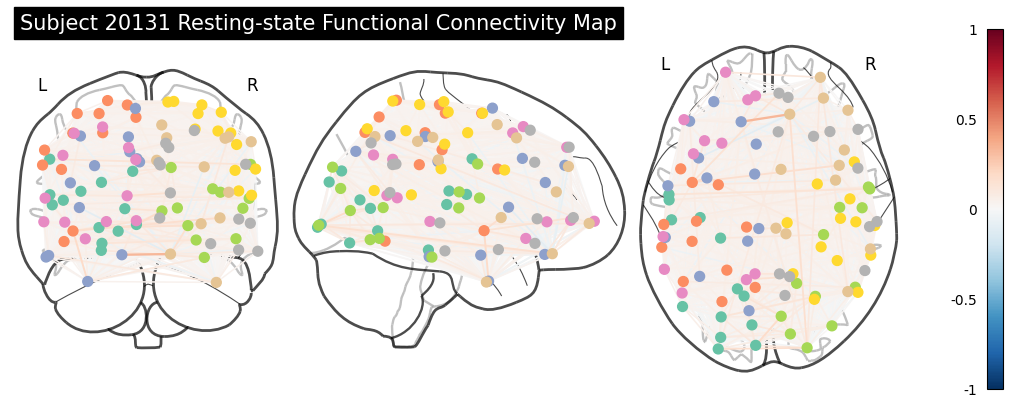

In [34]:
# Connectome
plot_connectome(
    partial_corr_matrix,
    atlas_coordinates,
    figure=plt.figure(figsize=(10,4)),
    edge_vmin=-1.0,
    edge_vmax=1.0,
    colorbar=True,
    title=f"Subject {sub_info['subject_id']} Resting-state Functional Connectivity Map"
)
show()

In [35]:
# binary-mask for active task regions
task_binary_mask = (masked_z_scores > 0).astype(int)
print(task_binary_mask)
print(len(task_binary_mask))

[0 0 1 1 1 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 0 1 1 1 0 1 0 0
 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1 1 0 0 0 0]
100


In [36]:
# matrix where entry (i, j) is 1 ONLY if BOTH regions i and j are task-active
connectivity_gate = np.outer(task_binary_mask, task_binary_mask)
print(connectivity_gate)
print(len(connectivity_gate), len(connectivity_gate[0]))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
100 100


In [45]:
# Task-gated connectivity
task_gated_corr_matrix = partial_corr_matrix * connectivity_gate
np.array(task_gated_corr_matrix).shape

(100, 100)

In [38]:
unique_gated_connections = task_gated_corr_matrix[upper_tri_indices]
num_active_gated_connections = np.count_nonzero(unique_gated_connections)
print(f"Subject {sub_info['subject_id']} - Task-Active Connections: {num_active_gated_connections}")

Subject 20131 - Task-Active Connections: 630


In [39]:
36*35//2, 100*99//2

(630, 4950)

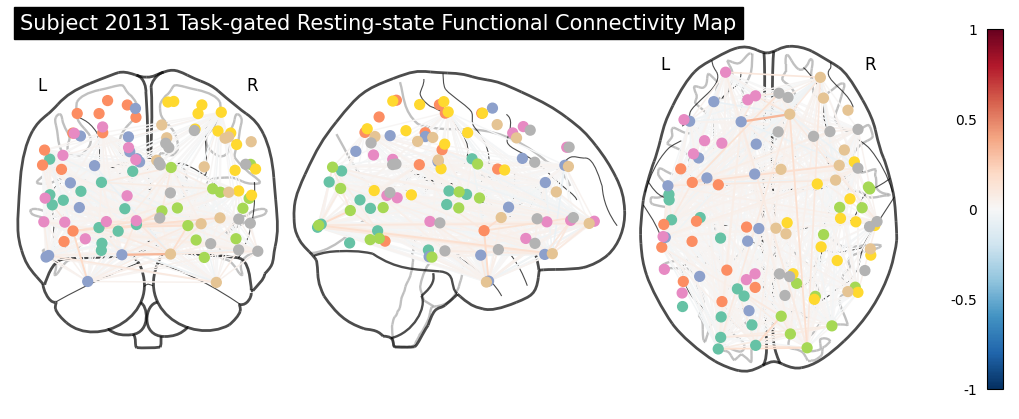

In [40]:
# Connectome
plot_connectome(
    task_gated_corr_matrix,
    atlas_coordinates,
    figure=plt.figure(figsize=(10,4)),
    edge_vmin=-1.0,
    edge_vmax=1.0,
    colorbar=True,
    title=f"Subject {sub_info['subject_id']} Task-gated Resting-state Functional Connectivity Map"
)
show()

https://share.google/aimode/pT8yPVrZCX4PUL2yI

In [41]:
node_mask = np.any(np.abs(task_gated_corr_matrix)>0, axis=1)
filtered_matrix = task_gated_corr_matrix[node_mask][:,node_mask]
filtered_coordinates = atlas_coordinates[node_mask]

In [43]:
filtered_matrix.shape

(36, 36)

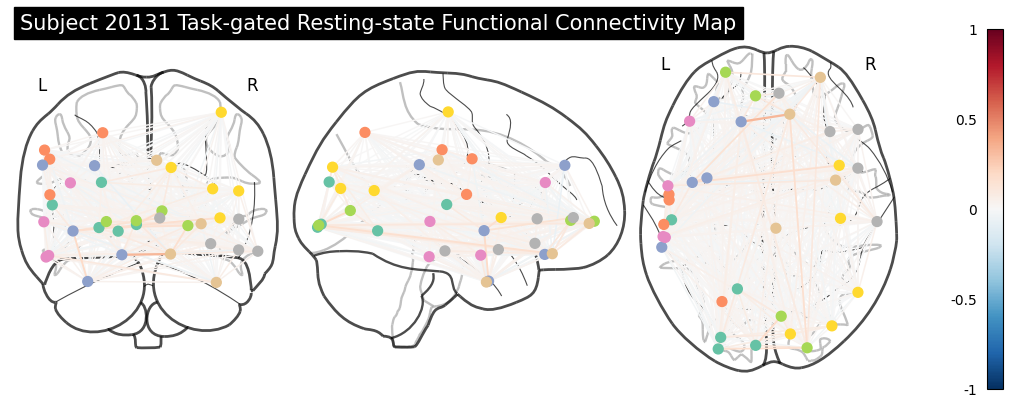

In [46]:
# Connectome
plot_connectome(
    filtered_matrix,
    filtered_coordinates,
    figure=plt.figure(figsize=(10,4)),
    edge_vmin=-1.0,
    edge_vmax=1.0,
    colorbar=True,
    title=f"Subject {sub_info['subject_id']} Task-gated Resting-state Functional Connectivity Map"
)
show()